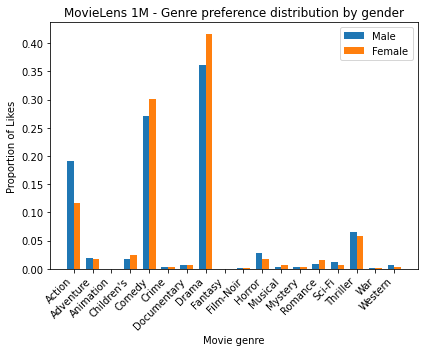

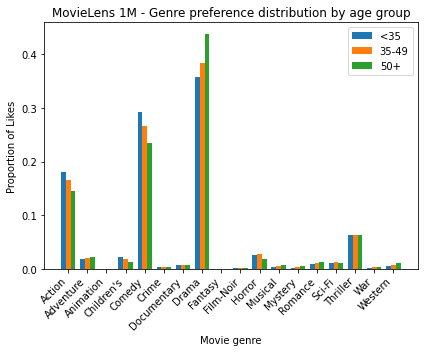

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import os

root = os.getcwd()
path_plot = "/home/peiretti/fair-clustering/plots/movielens-1m"

# --- Load data ---
matrix = np.load(root + "/matrix.npy").astype(int)
Sx = np.load(root + "/gender.npy").astype(int)
Sx_age = np.load(root + "/age.npy").astype(int)
genres = np.load(root + "/genres.npy").astype(int)

dict_genres = {
    'Action': 0,
    'Adventure': 1,
    'Animation': 2,
    "Children's": 3,
    'Comedy': 4,
    'Crime': 5,
    'Documentary': 6,
    'Drama': 7,
    'Fantasy': 8,
    'Film-Noir': 9,
    'Horror': 10,
    'Musical': 11,
    'Mystery': 12,
    'Romance': 13,
    'Sci-Fi': 14,
    'Thriller': 15,
    'War': 16,
    'Western': 17
}

genre_names = list(dict_genres.keys())
genre_ids = np.array(list(dict_genres.values()))

# --- Define "likes" ---
likes = (matrix >= 3).astype(int)

# -------------------------------------------------------------------
# Helper: compute normalized genre preferences for a protected attribute
# -------------------------------------------------------------------
def compute_group_genre_preferences(likes, group_labels, genres, genre_ids):
    """
    Returns a matrix pref[group, genre] where each row sums to 1.
    pref[g, k] = share of likes from group g that belong to genre k
    """
    unique_groups = np.unique(group_labels)
    pref = np.zeros((len(unique_groups), len(genre_ids)), dtype=float)

    for g_idx, g in enumerate(unique_groups):
        user_mask = (group_labels == g)

        # likes of users in this group: shape (#users_in_group, #movies)
        group_likes = likes[user_mask]

        # total number of likes received by each movie from this group
        movie_like_counts = group_likes.sum(axis=0)

        # aggregate by genre
        genre_like_counts = np.array([
            movie_like_counts[genres == genre_id].sum()
            for genre_id in genre_ids
        ], dtype=float)

        total_group_likes = genre_like_counts.sum()
        if total_group_likes > 0:
            pref[g_idx] = genre_like_counts / total_group_likes

    return unique_groups, pref


# --- Compute normalized preferences ---
gender_values, gender_pref = compute_group_genre_preferences(likes, Sx, genres, genre_ids)
age_values, age_pref = compute_group_genre_preferences(likes, Sx_age, genres, genre_ids)

# -------------------------------------------------------------------
# Label mappings
# Adjust these dictionaries if your encoding is different
# -------------------------------------------------------------------
gender_label_map = {
    0: "Male",
    1: "Female"
}

age_label_map = {
    0: "<35",
    1: "35-49",
    2: "50+"
}

gender_labels = [gender_label_map.get(v, f"Group {v}") for v in gender_values]
age_labels = [age_label_map.get(v, f"Group {v}") for v in age_values]

# -------------------------------------------------------------------
# Plot 1: Gender preferences
# -------------------------------------------------------------------
x = np.arange(len(genre_names))
bar_width = 0.35

plt.figure(figsize=(6,5))

for i, label in enumerate(gender_labels):
    offset = (i - (len(gender_labels) - 1) / 2) * bar_width
    plt.bar(x + offset, gender_pref[i], width=bar_width, label=label)

plt.xticks(x, genre_names, rotation=45, ha='right')
plt.ylabel("Proportion of Likes")
plt.xlabel("Movie genre")
plt.title("MovieLens 1M - Genre preference distribution by gender")
plt.legend()
plt.tight_layout()
plt.savefig(path_plot + "/gender_likes.png", dpi=300, bbox_inches="tight")
#plt.show()

# -------------------------------------------------------------------
# Plot 2: Age-group preferences
# -------------------------------------------------------------------
x = np.arange(len(genre_names))
bar_width = 0.25

plt.figure(figsize=(6,5))

for i, label in enumerate(age_labels):
    offset = (i - (len(age_labels) - 1) / 2) * bar_width
    plt.bar(x + offset, age_pref[i], width=bar_width, label=label)

plt.xticks(x, genre_names, rotation=45, ha='right')
plt.ylabel("Proportion of Likes")
plt.xlabel("Movie genre")
plt.title("MovieLens 1M - Genre preference distribution by age group")
plt.legend()
plt.tight_layout()
plt.savefig(path_plot + "/age_likes.png", dpi=300, bbox_inches="tight")
#plt.show()